# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [114]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from model import GradientBoostingModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
heart_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
#print(X_heart.shape, y_heart.value_counts().to_dict())

# Cancer genomics dataset
cancer_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/cancer_genomics.csv')
labels_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)
print(X_cancer.shape, y_cancer.value_counts().to_dict())
print(X_cancer.isna().sum())


Successfully loaded heart disease data with 1025 rows
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}
gene_18       0
gene_21       0
gene_26       0
gene_28       0
gene_29       0
             ..
gene_20500    0
gene_20504    0
gene_20514    0
gene_20524    0
gene_20529    0
Length: 5479, dtype: int64


In [116]:
# TODO: Initialize your model (adjust params)
model = GradientBoostingModel(
    task='classification',
    max_depth=3,
    learning_rate=0.1,
    n_estimators=50,
    use_scaler=False,
)


In [117]:
# TODO: Train/test split + fit (heart)
# X_train, X_test, y_train, y_test = model.train_test_split(...)
# model.fit(X_train, y_train)
X_train, X_test, y_train, y_test = model.train_test_split(X_heart, y_heart)
model.fit(X_train, y_train)


      Iter       Train Loss   Remaining Time 
         1           1.2784            0.10s
         2           1.1866            0.08s
         3           1.1129            0.08s
         4           1.0473            0.08s
         5           0.9846            0.08s
         6           0.9371            0.07s
         7           0.8898            0.07s
         8           0.8506            0.07s
         9           0.8135            0.06s
        10           0.7814            0.06s
        20           0.5716            0.04s
        30           0.4555            0.03s
        40           0.3883            0.01s
        50           0.3309            0.00s


In [119]:
# TODO: Evaluate (heart)
# metrics = model.evaluate(...)
# print metrics
print(y_test)
metrics = model.evaluate(X_test, y_test)
print(metrics)

527    1
359    1
447    0
31     1
621    0
      ..
832    1
796    1
644    1
404    0
842    0
Name: target, Length: 205, dtype: int64
Prediction is [1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0
 1 1 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0 1 0 0 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1
 1 1 0 1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1 1
 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 0 1
 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0 0]
{'accuracy': 0.8975609756097561, 'precision': 0.8995215311004785, 'recall': 0.897391966495336, 'f1': 0.897404732966326, 'roc_auc': np.float64(0.968303826384923), 'prediction': array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1

In [42]:
# TODO: Cross-validation (heart)
# cv_results = model.cross_validate(...)
# print metrics
cv_results = model.cross_validate(X_heart, y_heart, cv=3)
print(cv_results)

      Iter       Train Loss   Remaining Time 
         1           1.2863            0.10s
         2           1.1996            0.07s
         3           1.1294            0.06s
         4           1.0656            0.05s
         5           1.0133            0.05s
         6           0.9640            0.05s
         7           0.9237            0.04s
         8           0.8845            0.04s
         9           0.8522            0.04s
        10           0.8211            0.04s
        20           0.6148            0.03s
        30           0.5045            0.02s
        40           0.4272            0.01s
        50           0.3677            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.2787            0.04s
         2           1.1877            0.04s
         3           1.1103            0.04s
         4           1.0427            0.04s
         5           0.9877            0.04s
         6           0.9406            0.04s
        

In [51]:
# TODO: Feature importance (heart)
# model.get_feature_importance(plot=False)
feature_importance = model.get_feature_importance(plot=False)
print(feature_importance.head(15))


           0
0   0.050962
1   0.021163
2   0.286104
3   0.030444
4   0.045539
5   0.000000
6   0.004827
7   0.046694
8   0.021780
9   0.116869
10  0.042440
11  0.170406
12  0.162773


In [44]:
# TODO: Hyperparameter tuning (heart)
param_grid = {
    # 'max_depth': [...],
    # 'n_estimators': [...],
    # 'learning_rate': [...],
    'max_depth': [3, 10, 45],
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.001, 0.0001, 0.5]
}
tuning_results = model.tune_hyperparameters(X_heart, y_heart, param_grid, cv=3)
print(tuning_results)


      Iter       Train Loss   Remaining Time 
         1           1.2863            0.10s
         2           1.1996            0.08s
         3           1.1294            0.06s
         4           1.0656            0.06s
         5           1.0133            0.05s
         6           0.9640            0.05s
         7           0.9237            0.05s
         8           0.8845            0.05s
         9           0.8522            0.04s
        10           0.8211            0.04s
        20           0.6148            0.03s
        30           0.5045            0.02s
        40           0.4272            0.01s
        50           0.3677            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.2787            0.04s
         2           1.1877            0.04s
         3           1.1103            0.04s
         4           1.0427            0.04s
         5           0.9877            0.04s
         6           0.9406            0.04s
        

In [48]:
# TODO: Train/evaluate on cancer dataset (multi-class)
# cancer_model = GradientBoostingModel(...)
# cancer_model.train_test_split(...)
# fit
# evaluate 
# print metrics

cancer_model = GradientBoostingModel(task="classification", max_depth=10, learning_rate=0.1, n_estimators=50, use_scaler=True)
X_train, X_test, y_train, y_test = cancer_model.train_test_split(X_cancer, y_cancer, test_size=0.2)
cancer_model.fit(X_train, y_train)
metrics = cancer_model.evaluate(X_test, y_test)
print(metrics)
y_true = y_test
y_pred = metrics["prediction"]


      Iter       Train Loss   Remaining Time 
         1           1.1337            2.53m
         2           0.9033            3.55m
         3           0.7357            3.62m
         4           0.6066            3.67m
         5           0.5041            3.67m
         6           0.4213            3.58m
         7           0.3535            3.51m
         8           0.2974            3.44m
         9           0.2509            3.36m
        10           0.2120            3.28m
        20           0.0413            2.44m
        30           0.0083            1.62m
        40           0.0017           48.43s
        50           0.0003            0.00s
Prediction is ['LUAD' 'BRCA' 'LUAD' 'KIRC' 'BRCA' 'BRCA' 'BRCA' 'COAD' 'PRAD' 'LUAD'
 'COAD' 'BRCA' 'LUAD' 'PRAD' 'KIRC' 'LUAD' 'LUAD' 'PRAD' 'BRCA' 'LUAD'
 'LUAD' 'COAD' 'KIRC' 'BRCA' 'BRCA' 'BRCA' 'COAD' 'BRCA' 'PRAD' 'PRAD'
 'BRCA' 'PRAD' 'PRAD' 'COAD' 'BRCA' 'BRCA' 'LUAD' 'BRCA' 'LUAD' 'BRCA'
 'COAD' 'BRCA' 'BRCA' 'BRC

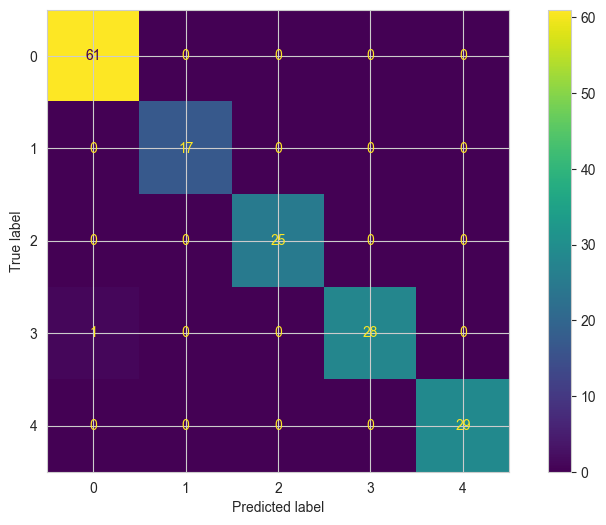

In [49]:
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [40]:
cv_results_cancer = cancer_model.cross_validate(X_cancer, y_cancer, cv=3)
print(cv_results_cancer)

      Iter       Train Loss   Remaining Time 
         1           1.1345            1.29m
         2           0.9038            2.40m
         3           0.7360            2.56m
         4           0.6069            2.58m
         5           0.5043            2.56m
         6           0.4215            2.54m
         7           0.3536            2.48m
         8           0.2976            2.44m
         9           0.2510            2.41m
        10           0.2121            2.35m
        20           0.0413            1.79m
        30           0.0083            1.20m
        40           0.0017           35.97s
        50           0.0003            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.1346            1.40m
         2           0.9039            2.31m
         3           0.7361            2.46m
         4           0.6069            2.63m
         5           0.5044            2.64m
         6           0.4215            2.61m
        

In [ ]:
param_grid = {
    'max_depth': [3, 10, 45],
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.001, 0.0001, 0.5]
}

tuning_results_cancer = cancer_model.tune_hyperparameters(X_cancer, y_cancer, param_grid=param_grid, cv=3, scoring="roc_auc_ovo")
print(tuning_results_cancer)

      Iter       Train Loss   Remaining Time 
         1           1.1345            1.30m
         2           0.9038            1.69m
         3           0.7360            1.81m
         4           0.6069            1.86m
         5           0.5043            1.87m
         6           0.4215            1.87m
         7           0.3536            1.86m
         8           0.2976            1.84m
         9           0.2510            1.81m
        10           0.2121            1.78m
        20           0.0413            1.37m
        30           0.0083           55.50s
        40           0.0017           27.89s
        50           0.0003            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.1346            1.35m
         2           0.9039            1.74m
         3           0.7361            1.88m
         4           0.6069            1.92m
         5           0.5044            1.92m
         6           0.4215            1.91m
        

In [69]:
feature_importances = cancer_model.get_feature_importance(plot=False)
cancer_feature_importance = pd.Series(feature_importances, index=X_cancer.columns)
sortedfeatureimportance = cancer_feature_importance.sort_values(ascending=False)
print(sortedfeatureimportance.head(15))

gene_18746    0.289920
gene_12983    0.202877
gene_15895    0.181088
gene_12013    0.114803
gene_18135    0.063933
gene_9176     0.055736
gene_8014     0.033764
gene_203      0.033430
gene_6160     0.006149
gene_6876     0.005088
gene_9394     0.002145
gene_5803     0.000883
gene_17904    0.000703
gene_2730     0.000655
gene_20389    0.000576
dtype: float64


In [ ]:
"""
from hw2_loader import HW2DataLoader
loader = HW2DataLoader()
cancer_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/cancer_genomics.csv')
labels_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer)
hdc = HeartDiseaseClassifier()
X_train_preprocessed = hdc.preprocess_features(X_train)
X_test_preprocessed = hdc.preprocess_features(X_test, train=False)
print(X_train_preprocessed)
hdc.fit(X_train_preprocessed[["gene_18746", "gene_12983", "gene_15895", "gene_12013", "gene_18135", "gene_9176", "gene_8014", "gene_203", "gene_6160", "gene_6876", "gene_9394", "gene_5803", "gene_17904", "gene_2730", "gene_20389"]], y_train, scaling=True)
results = hdc.evaluate(X_test_preprocessed[["gene_18746", "gene_12983", "gene_15895", "gene_12013", "gene_18135", "gene_9176", "gene_8014", "gene_203", "gene_6160", "gene_6876", "gene_9394", "gene_5803", "gene_17904", "gene_2730", "gene_20389"]], y_test)
print("[Evaluation Metrics]\n")
print("Accuracy Score: " + str(results["accuracy_score"]))
print("Precision Score: " + str(results["precision_score"]))
print("Recall Score: " + str(results["recall_score"]))
print("F1 Score: " + str(results["f1_score"]))
print("AUC: " + str(results["auc"]))
"""

In [ ]:
"""
from hw2_loader import HW2DataLoader
loader = HW2DataLoader()
cancer_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/cancer_genomics.csv')
labels_path = Path('/Users/ronitdas/Documents/GitHub/homework-2-Fossilbullet/homework2/data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer)
# TODO: impute missing values on train, then apply to val (avoid leakage)
hdc = HeartDiseaseClassifier()
X_train_preprocessed = hdc.preprocess_features(X_train)
X_test_preprocessed = hdc.preprocess_features(X_test, train=False)
print(X_train_preprocessed)
hdc.fit(X_train_preprocessed, y_train, scaling=True)
results = hdc.evaluate(X_test_preprocessed, y_test)
print("[Evaluation Metrics]\n")
print("Accuracy Score: " + str(results["accuracy_score"]))
print("Precision Score: " + str(results["precision_score"]))
print("Recall Score: " + str(results["recall_score"]))
print("F1 Score: " + str(results["f1_score"]))
print("AUC: " + str(results["auc"]))
"""